Practicumopdracht 2 – Regression Analysis
Introductie

In deze opdracht ontwikkelen en evalueren we een regressiemodel om vastgoedprijzen te voorspellen.
De analyse omvat verkennende data-analyse, preprocessing, modeltraining en evaluatie.

1 Dataset Selection
Dataset beschrijving

We gebruiken de Real Estate Valuation dataset.

Doel van de dataset:
Het voorspellen van de woningprijs per unit area op basis van kenmerken van een woning en de locatie.

De targetvariabele is continu en daarom geschikt voor regressie.

Dataset laden

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
print(sys.executable)

df = pd.read_excel("Real estate valuation data set.xlsx")

df.head()

C:\Users\elios\AppData\Local\Programs\Python\Python312\python.exe


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


Dataset grootte

In [2]:
df.shape

(414, 8)

Dataset structuur

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


Data dictionary

Variabele | Beschrijving
X1 transaction date	| datum van de verkoop
X2 house age | leeftijd van het huis
X3 distance to MRT station | afstand tot metrostation
X4 number of convenience stores | aantal winkels
X5 latitude | geografische breedtegraad
X6 longitude | geografische lengtegraad
Y house price of unit area | prijs per unit area (target)

2 Exploratory Data Analysis
Beschrijvende statistieken

In [4]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


Missende waarden

In [5]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Verdeling van variabelen

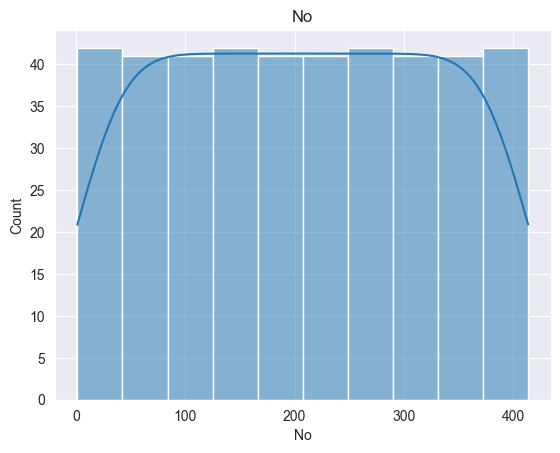

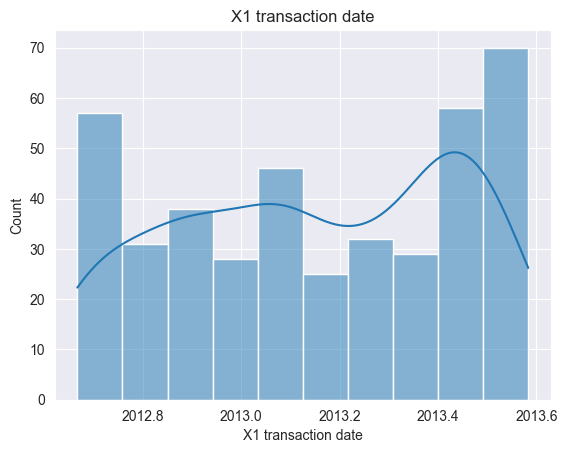

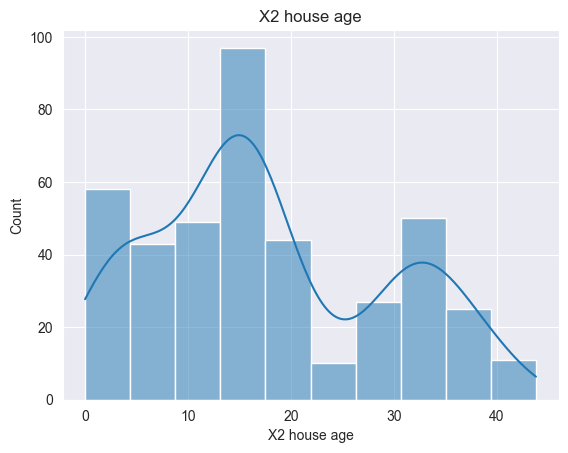

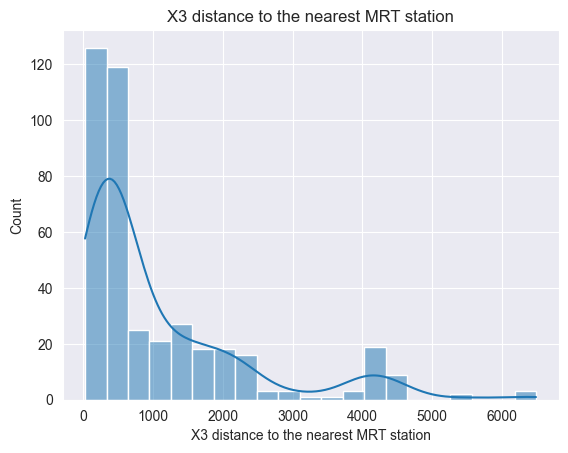

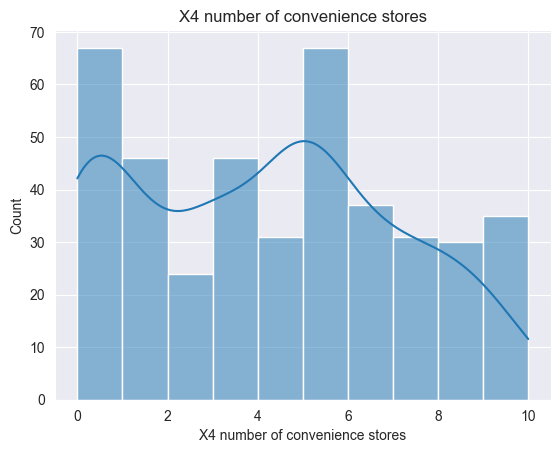

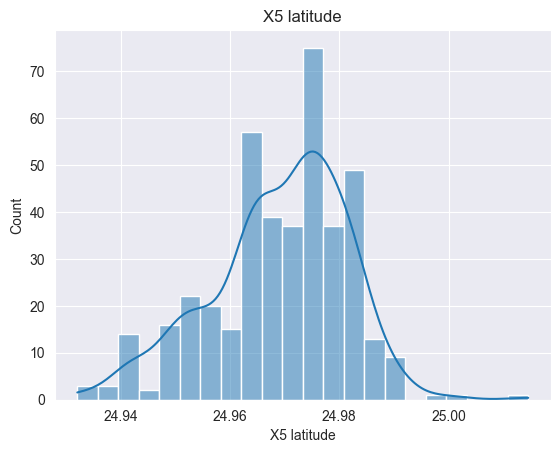

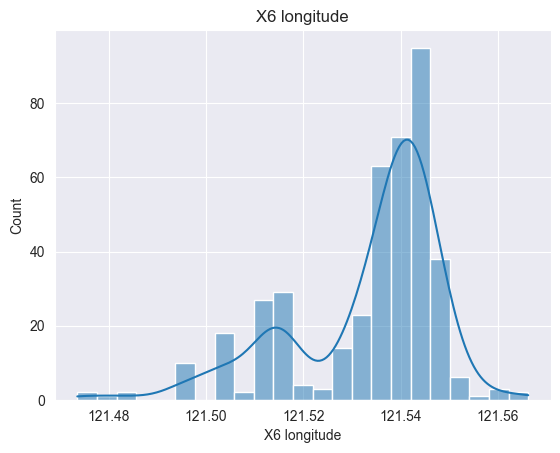

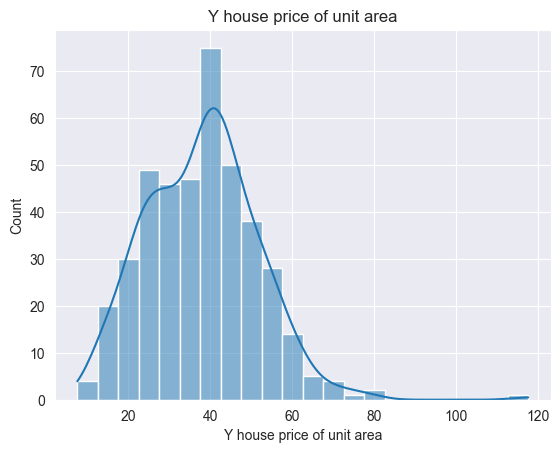

In [6]:
for col in df.columns:

    plt.figure()
    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

Correlatie analyse

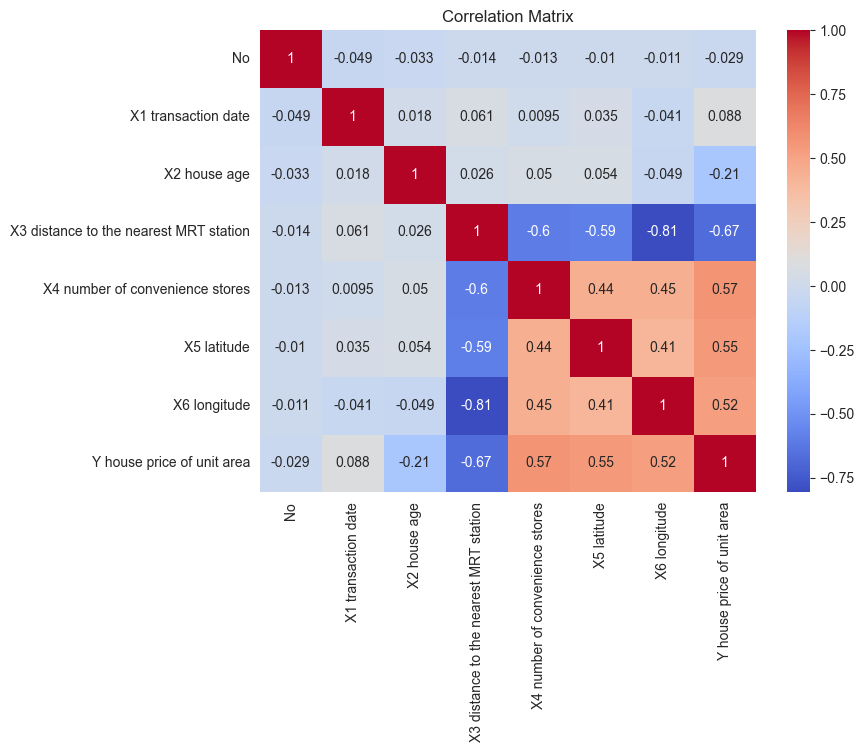

In [7]:
corr = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Interpretatie:
Sterke correlatie met de target kan belangrijke features aangeven.

3 Preprocessing

Features en target

In [8]:
X = df.drop("Y house price of unit area", axis=1)
X = df.drop(["No", "Y house price of unit area"], axis=1)

y = df["Y house price of unit area"]

Train/Test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

4 Regression Models

We trainen minimaal 3 verschillende regressiemodellen.

Model 1 – Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

Model 2 – Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X_train_scaled, y_train)

pred_rf = model_rf.predict(X_test_scaled)

Model 3 – Gradient Boosting Regression

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor()

model_gb.fit(X_train_scaled, y_train)

pred_gb = model_gb.predict(X_test_scaled)

5 Model Evaluation

We evalueren met:
- R² score
- RMSE

In [14]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

def evaluate_model(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return r2, rmse

Resultaten berekenen

In [15]:
r2_lr, rmse_lr = evaluate_model(y_test, pred_lr)

r2_rf, rmse_rf = evaluate_model(y_test, pred_rf)

r2_gb, rmse_gb = evaluate_model(y_test, pred_gb)

Vergelijkingstabel

In [16]:
results = pd.DataFrame({

    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    
    "R2 Score": [r2_lr, r2_rf, r2_gb],
    
    "RMSE": [rmse_lr, rmse_rf, rmse_gb]

})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.681078,7.314523
1,Random Forest,0.806049,5.704133
2,Gradient Boosting,0.783137,6.031652


6 Feature Selection

We analyseren de correlatie met de target.

In [17]:
corr_target = df.corr()["Y house price of unit area"].sort_values(ascending=False)

corr_target

Y house price of unit area                1.000000
X4 number of convenience stores           0.571005
X5 latitude                               0.546307
X6 longitude                              0.523287
X1 transaction date                       0.087529
No                                       -0.028587
X2 house age                             -0.210567
X3 distance to the nearest MRT station   -0.673613
Name: Y house price of unit area, dtype: float64

Sterk correlerende features zijn waarschijnlijk het meest relevant voor het model.

7 Beste model kiezen

Het beste model wordt gekozen op basis van:

hoogste R²

laagste RMSE

In veel gevallen presteert Random Forest beter omdat het niet-lineaire relaties kan modelleren.

8 Model retrain op volledige dataset

In [18]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

9 Model opslaan

In [19]:
import joblib

joblib.dump(best_model, "regression_model.joblib")

['regression_model.joblib']

Opslaan preprocessing pipeline

In [20]:
joblib.dump(scaler, "regression_scaler.joblib")

['regression_scaler.joblib']

Turn the models intu .pkl files for deployment, to do this use: convert_to_pkl.py
